In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd


In [12]:
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
X_val = pd.read_csv("../data/processed/X_val.csv")
y_val = pd.read_csv("../data/processed/y_val.csv").squeeze()

/home/bahoore/projects/diabetes-prediction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


              precision    recall  f1-score   support

           0       0.86      0.97      0.91     32056
           1       0.55      0.19      0.28      5996

    accuracy                           0.85     38052
   macro avg       0.71      0.58      0.60     38052
weighted avg       0.82      0.85      0.81     38052



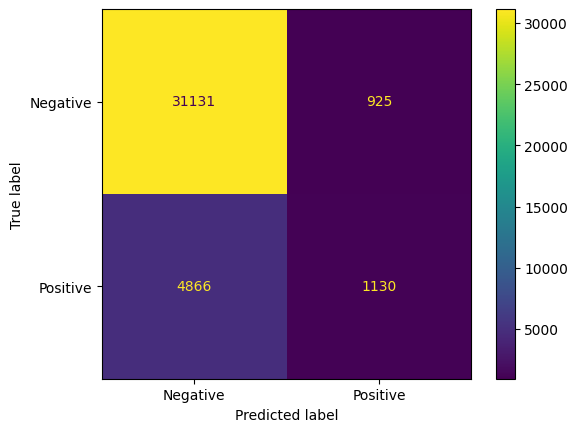

In [19]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

linear_pipeline.fit(
    X_train,
    y_train
)

y_prob = linear_pipeline.predict_proba(X_val)[:,1]

y_pred = linear_pipeline.predict(X_val)

print(
    classification_report(
        y_val,
        y_pred
    )
)

roc_auc_score(
    y_val,
    y_prob
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred,
    display_labels=["Negative", "Positive"]
)

plt.show()